> Module: Deep learning<br>
> Assignment: 1<br>
> Name: Chun-Yuan Chen<br>

# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [✅] Inspect the shapes of the training and test sets to confirm their size and structure.
- [✅] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [✅] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
    # CYC notes: Images are stored with gray pixel values ranging from 0 to 255.
    # CYC notes: Why normalization: train better, helps gradient calculations stay consistent.
        # Reference: https://lamiae-hana.medium.com/an-intro-to-convolutional-neural-networks-cnn-9f1c2d888fa1
X_train = X_train.astype('float32') / 255.0 
X_test = X_test.astype('float32') / 255.0   

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [2]:
# Inspect the shapes of the datasets
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

# CYC added: before one-hot encoding y, to see their frequency distribution.
import pandas as pd
import numpy as np
y_train_dist = pd.Series(y_train).value_counts().sort_index()
y_test_dist  = pd.Series(y_test).value_counts().sort_index()
label_freq_table = pd.DataFrame({'Class': y_train_dist.index, 'Train Count': y_train_dist.values, 'Test Count': y_test_dist.values})
print(label_freq_table)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train_onehot = to_categorical(y_train)
y_test_onehot  = to_categorical(y_test)
print(y_train_onehot[:5])
print(y_test_onehot[:5])

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
   Class  Train Count  Test Count
0      0         6000        1000
1      1         6000        1000
2      2         6000        1000
3      3         6000        1000
4      4         6000        1000
5      5         6000        1000
6      6         6000        1000
7      7         6000        1000
8      8         6000        1000
9      9         6000        1000
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]]


> CYC notes:<br>
>
> Based on the shapes output:<br>
> 
> X_train has 60000 images (each 28×28 pixels, 1 layer of pixel intensity), y_train has 60000 labels for training.<br>
>
> X_test has 10000 images (each 28×28 pixels, 1 layer of pixel intensity), y_test has 10000 labels for testing.<br>
>
> Reference: https://medium.com/featurepreneur/understanding-the-concept-of-channels-in-an-image-6d59d4dafaa9

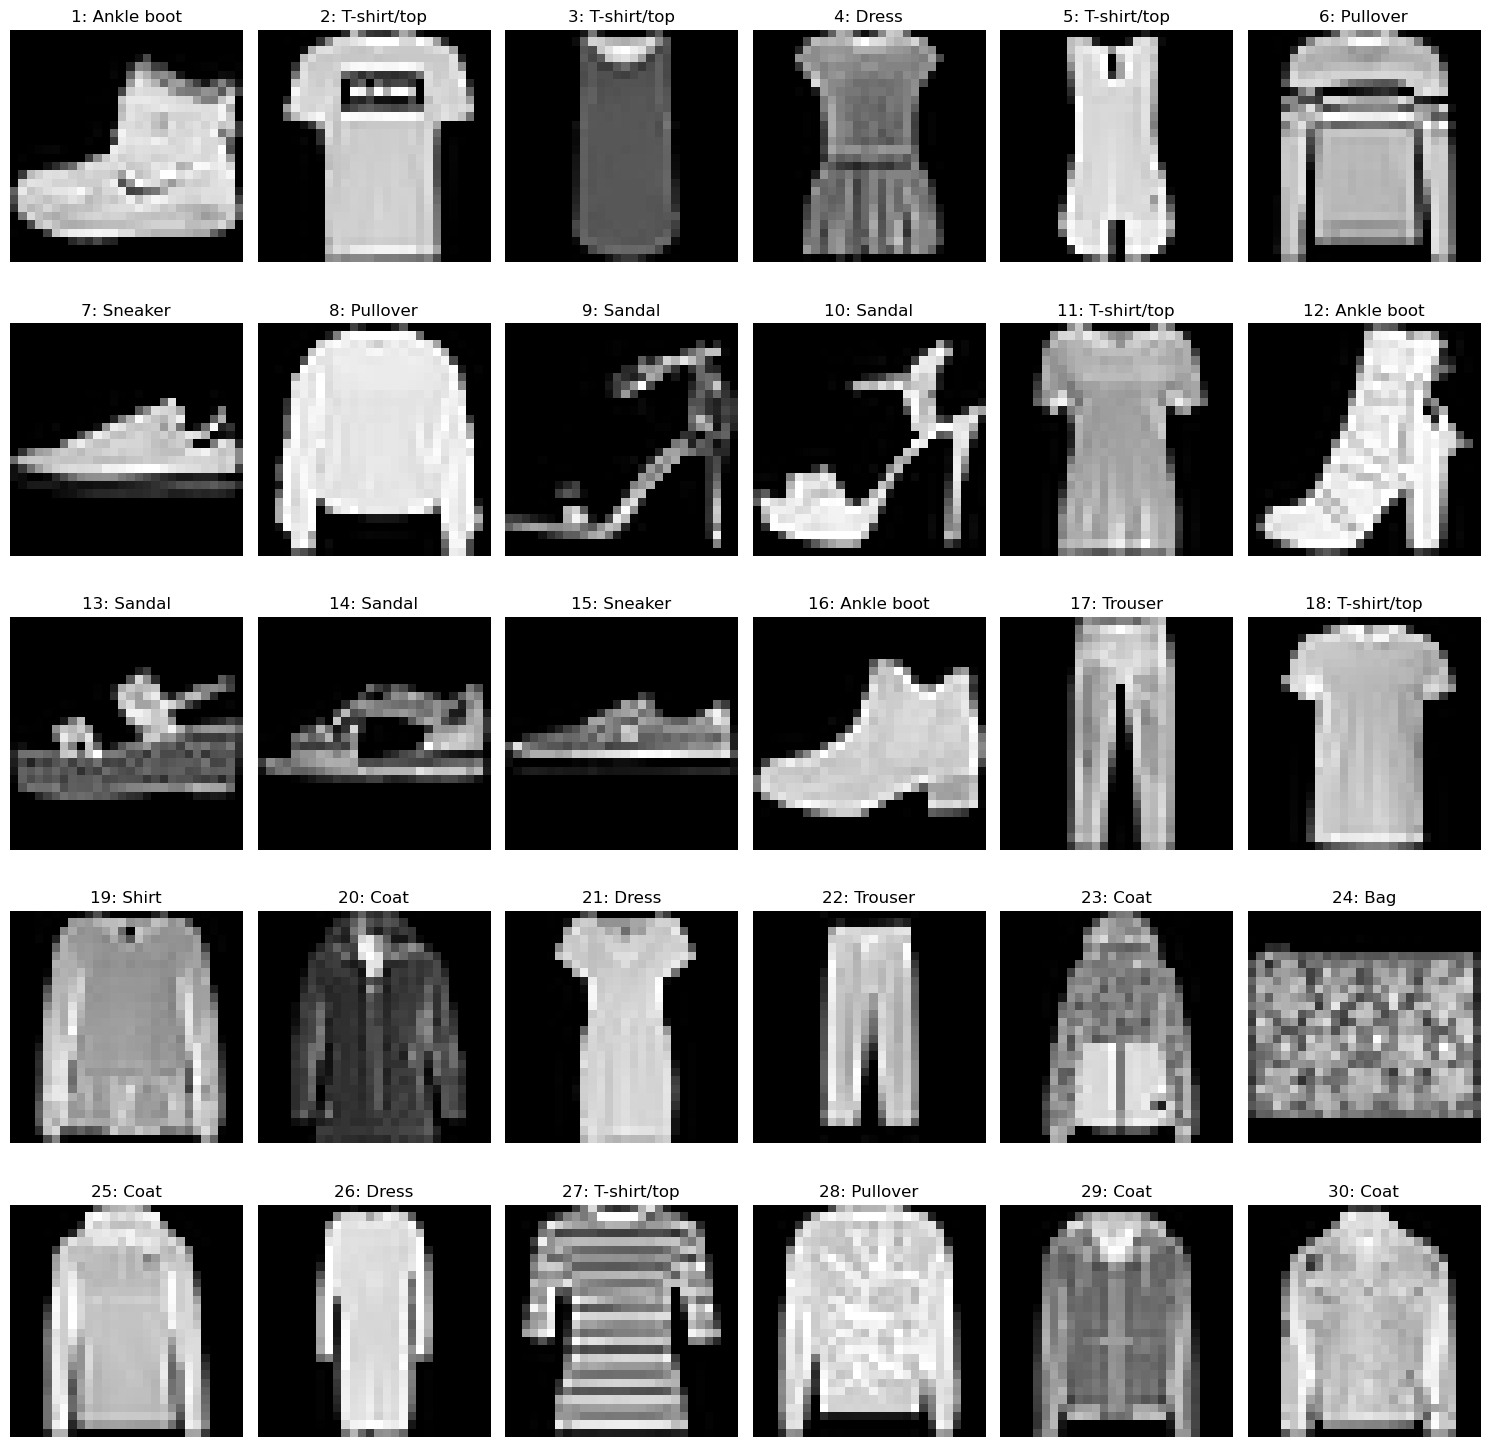

In [3]:
# Visualize a few images from the dataset to understand what the data looks like.
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 15))
for i in range(30):
    plt.subplot(5, 6, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"{i+1}: {class_names[y_train[i]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

**Your answer here**

The dataset (the visuals) looks as expected. It is pretty low resolution, which makes it good for testing models quickly or good for simple tasks, but not ideal for capturing fine and nuanced details. In my view, most clothing items are easy to recognize, and the labels generally match what is represented. However, some different classes (e.g., coat in 25 vs. dress in 26, and pullover in 28 vs. coat in 29) look highly similar by human eye, as well as which could confuse a model. In addition there is no color (e.g., red, blue, etc.) or texture, it is not suitable for distinguishing real-world cases. In overall, it is a simple dataset that is fair enough for simple prototyping, but it does have its obvious limits if aiming for something more nuanced.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [✅] Create a simple linear regression model using Keras.
- [✅] Compile the model with an appropriate loss function and optimizer.
- [✅] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [7]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Input
from keras.optimizers import SGD

# Reference: https://stackoverflow.com/questions/51181393/simple-linear-regression-using-keras

# Create a simple linear regression model
model_base = Sequential()

# You can use `model.add(<layer>)` to add layers to the model
model_base.add(Input(shape=(28, 28))) # Each image is 28×28 pixels, telling what input to expect.
model_base.add(Flatten()) # Flatten 2D image into a 1D vector of 28×28 values.
model_base.add(Dense(1)) # Linear regression: so setting 1 as predicting a single continuous value, not 10 class scores.

# Compile the model using `model.compile()`
model_base.compile(optimizer=SGD(learning_rate=0.001), loss='mean_squared_error', metrics=['mean_absolute_error'])
    # mean_squared_error: could help penalize large errors more heavily >>> better convergence.
    # mean_absolute_error: direct way to get how far off predictions are.

# Train the model with `model.fit()`
model_base.fit(X_train, y_train, epochs=15, batch_size=64, validation_split=0.3)

# Evaluate the model with `model.evaluate()`
    # Test loss (MSE) and Test MAE
test_loss, test_mae = model_base.evaluate(X_test, y_test)
print(f"Test loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")

    # Get rounded accuracy for later comparison with CNN
    # Reference: https://stackoverflow.com/questions/42665359/how-do-you-compute-accuracy-in-a-regression-model-after-rounding-predictions-to
y_pred_base = model_base.predict(X_test)
y_pred_base_rounded = np.round(y_pred_base).astype(int)
y_pred_base_rounded = np.clip(y_pred_base_rounded, 0, 9) # make predictions stay within the specified range (labels 0 to 9).
rounded_accuracy_base = np.mean(y_pred_base_rounded.flatten() == y_test) # Compares the rounded predictions to the true labels and computes the proportion of matches.
print(f"Rounded Accuracy: {rounded_accuracy_base:.4f}")

Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5.2062 - mean_absolute_error: 1.7501 - val_loss: 3.1483 - val_mean_absolute_error: 1.3368
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.1060 - mean_absolute_error: 1.3172 - val_loss: 2.8681 - val_mean_absolute_error: 1.2724
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.8461 - mean_absolute_error: 1.2583 - val_loss: 2.6754 - val_mean_absolute_error: 1.2214
Epoch 4/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.6959 - mean_absolute_error: 1.2281 - val_loss: 2.5314 - val_mean_absolute_error: 1.1863
Epoch 5/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.5488 - mean_absolute_error: 1.1801 - val_loss: 2.4258 - val_mean_absolute_error: 1.1608
Epoch 6/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.4433 - mean_absolute_error: 1.1581 - val_loss: 2.3407 - val_mean_absolute_error: 1.1385
Epoch 7/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.3452 - mean_absolute_error: 1.1330 - v

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

**Your answer here**

The baseline (linear regression) model's performance is not good. It is only getting around 35% accuracy. I am not surprised because it is just a very simple model, way too basic for a vision task like this. In terms of linear regression view, this model basically is just trying to classify complex images just from pure pixels, there is not a lot of info there and limited to  the hidden patterns in the images. This suggests why a complex models like CNN (even the simplest version) is expected to be better than linear regression. CNNs can "see" what a linear model can't see! However, the baseline model serves as a great reminder to see how much improvement we can get later on with a complex model.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [✅] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [✅] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [✅] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [ ]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam

# Reference: https://www.tensorflow.org/tutorials/images/cnn

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)
    # -1: tell NumPy to automatically figure out how many samples there are.
    # 28: image height.
    # 28: image width.
    # 1: 1 channel.

# Create a simple CNN model
model_cnn = Sequential()

model_cnn.add(Input(shape=(28, 28, 1))) 

model_cnn.add(Conv2D(32, kernel_size=(3, 3), activation='relu')) # to detect complex local patterns like edges, curves, textures, etc.
    # 32: #filters, which each learns a different pattern. More filters >>> more feature extraction.
    # (3, 3): common size of each filter to capture fined details in images.

model_cnn.add(MaxPooling2D(pool_size=(2, 2))) # to reduce spatial dimensions while retaining the most important info.
    # for pooling window size, taking the max value for each 2×2 block.

model_cnn.add(Flatten()) # to convert 2D feature maps into a 1D vector for later use in fully connected layers

model_cnn.add(Dense(128, activation='relu')) # a fully connected layer with 128 neurons
    # More neurons >>> more learning capacity

model_cnn.add(Dense(10, activation='softmax')) # outputs probs for each of the clothing classes

model_cnn.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model_cnn.fit(X_train, y_train_onehot, epochs=15, batch_size=64, validation_split=0.3)
    # epochs=15, batch_size=64, validation_split=0.3 set the same as in the base line model.

# Evaluate the model
test_loss, test_accuracy = model_cnn.evaluate(X_test, y_test_onehot)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7887 - loss: 0.6113 - val_accuracy: 0.8773 - val_loss: 0.3438
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8923 - loss: 0.3018 - val_accuracy: 0.8934 - val_loss: 0.2937
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9086 - loss: 0.2499 - val_accuracy: 0.8905 - val_loss: 0.3067
Epoch 4/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9200 - loss: 0.2173 - val_accuracy: 0.9033 - val_loss: 0.2705
Epoch 5/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9313 - loss: 0.1908 - val_accuracy: 0.9100 - val_loss: 0.2514
Epoch 6/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9396 - loss: 0.1647 - val_accuracy: 0.9121 - val_loss: 0.2508
Epoch 7/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9485 - loss: 0.1430 - val_accuracy: 0.9122 - val_loss: 0.2613
Epoch 8/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9561 - loss: 0.1230 - val_accuracy: 0.

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

**Your answer here**

Absolutely! The CNN model (test accuracy = 0.9107) crushed the baseline (test accuracy in terms of rounded accuracy = 0.3679), which is a significant improvement. There are several reasons behind such improvement in my perspective: (1) the baseline model has no spatial awareness and cannot detect local patterns; (2) the CNN hasthe Conv2D layer to learn edges, curves, etc.; and (3) the CNN has the Dense layer with 128 neurons to learns complex combinations of features, complexy, and intricate patterns.

# 4. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [✅] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [✅] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [✅] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [✅] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [ ]:
# A. Test Hyperparameters (I chose kernel size with three different values to test)
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from keras.optimizers import Adam

kernel_sizes = [(3, 3), (5, 5), (7, 7)]
kernel_results = {}

for ks in kernel_sizes:
    print(f"\nTesting kernel size: {ks}")
    
    # Basically, the architecture is the same as what used in section 3.
    model_test1 = Sequential()
    model_test1.add(Input(shape=(28, 28, 1)))
    model_test1.add(Conv2D(32, kernel_size=ks, activation='relu'))
    model_test1.add(MaxPooling2D(pool_size=(2, 2)))
    model_test1.add(Flatten())
    model_test1.add(Dense(128, activation='relu'))
    model_test1.add(Dense(10, activation='softmax'))

    model_test1.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

    model_test1.fit(X_train, y_train_onehot, epochs=15, batch_size=64, validation_split=0.3)

    test_loss, test_accuracy = model_test1.evaluate(X_test, y_test_onehot)
    kernel_results[ks] = test_accuracy

# Print all test accuracies in three scenarios in terms of three different kernel sizes. 
print("\nFinal Test Accuracies:")
for ks, acc in kernel_results.items():
    print(f"Kernel size {ks}: Test accuracy = {acc:.4f}")


Testing kernel size: (3, 3)
Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7851 - loss: 0.6204 - val_accuracy: 0.8761 - val_loss: 0.3531
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8925 - loss: 0.3040 - val_accuracy: 0.8962 - val_loss: 0.2943
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9097 - loss: 0.2521 - val_accuracy: 0.9049 - val_loss: 0.2691
Epoch 4/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9155 - loss: 0.2267 - val_accuracy: 0.9049 - val_loss: 0.2648
Epoch 5/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9277 - loss: 0.1941 - val_accuracy: 0.9136 - val_loss: 0.2475
Epoch 6/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9365 - loss: 0.1715 - val_accuracy: 0.9142 - val_loss: 0.2457
Epoch 7/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9427 - loss: 0.1543 - val_accuracy: 0.9127 - val_loss: 0.2493
Epoch 8/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9523 - lo

In [17]:
# B. Test presence or absence of regularization (I chose L2 regularization to test)

# Reference: https://keras.io/api/layers/regularizers/

from keras.regularizers import l2

l2_scenarios = [None, l2(0.01)] # May reduce overfitting more aggressively than others less (e.g., 0.005, 0.001)
l2_labels    = ['No L2', 'L2 with λ=0.01']
l2_results   = {}

for l2_scenario, label in zip(l2_scenarios, l2_labels):
    print(f"\nTesting regularization: {label}")
    
    # Basically, the architecture is the same as what used in section 3 but with kernel_regularizer settings.
    model_test2 = Sequential()
    model_test2.add(Input(shape=(28, 28, 1)))
    model_test2.add(Conv2D(32, kernel_size=(3, 3), activation='relu', kernel_regularizer=l2_scenario)) # applies a penalty to the weights of the layer or not.
    model_test2.add(MaxPooling2D(pool_size=(2, 2)))
    model_test2.add(Flatten())
    model_test2.add(Dense(128, activation='relu', kernel_regularizer=l2_scenario)) # applies a penalty to the weights of the layer or not.
    model_test2.add(Dense(10, activation='softmax'))

    model_test2.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

    model_test2.fit(X_train, y_train_onehot, epochs=15, batch_size=64, validation_split=0.3)

    test_loss, test_accuracy = model_test2.evaluate(X_test, y_test_onehot)
    l2_results[label] = test_accuracy

# Print all test accuracies in two scenarios in terms of without or with L2 regularization. 
print("\nFinal Test Accuracies with Regularization:")
for label, acc in l2_results.items():
    print(f"{label}: Test accuracy = {acc:.4f}")


Testing regularization: No L2
Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7928 - loss: 0.6112 - val_accuracy: 0.8703 - val_loss: 0.3584
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8881 - loss: 0.3087 - val_accuracy: 0.8841 - val_loss: 0.3191
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9052 - loss: 0.2604 - val_accuracy: 0.9048 - val_loss: 0.2687
Epoch 4/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9197 - loss: 0.2218 - val_accuracy: 0.8992 - val_loss: 0.2743
Epoch 5/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9288 - loss: 0.1965 - val_accuracy: 0.9037 - val_loss: 0.2682
Epoch 6/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9391 - loss: 0.1637 - val_accuracy: 0.9140 - val_loss: 0.2467
Epoch 7/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9472 - loss: 0.1454 - val_accuracy: 0.9134 - val_loss: 0.2524
Epoch 8/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9528 - 

In [18]:
# C. Test the combination scenarios from A and B. 
# CYC notes: I added this cell to test their combinations.

kernel_sizes = [(3, 3), (5, 5), (7, 7)]
l2_scenarios = [None, l2(0.01)]
l2_labels = ['No L2', 'L2 with λ=0.01']

combo = {}

# Loop through six scenarios
for ks in kernel_sizes:
    for l2_scenario, label in zip(l2_scenarios, l2_labels):
        print(f"\nTesting kernel size {ks} with regularization: {label}")
        
        model_test3 = Sequential()
        model_test3.add(Input(shape=(28, 28, 1)))
        model_test3.add(Conv2D(32, kernel_size=ks, activation='relu', kernel_regularizer=l2_scenario))
        model_test3.add(MaxPooling2D(pool_size=(2, 2)))
        model_test3.add(Flatten())
        model_test3.add(Dense(128, activation='relu', kernel_regularizer=l2_scenario))
        model_test3.add(Dense(10, activation='softmax'))

        model_test3.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

        model_test3.fit(X_train, y_train_onehot, epochs=15, batch_size=64, validation_split=0.3)

        test_loss, test_accuracy = model_test3.evaluate(X_test, y_test_onehot)
        
        combo[(ks, label)] = test_accuracy

# Print all test accuracies for six scenarios
print("\nFinal Test Accuracies for Kernel Size and Regularization Combinations:")
for (ks, label), acc in combo.items():
    print(f"Kernel size {ks}, {label}: Test accuracy = {acc:.4f}")


Testing kernel size (3, 3) with regularization: No L2
Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7859 - loss: 0.6222 - val_accuracy: 0.8757 - val_loss: 0.3466
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8900 - loss: 0.3118 - val_accuracy: 0.8960 - val_loss: 0.2995
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9078 - loss: 0.2546 - val_accuracy: 0.8982 - val_loss: 0.2868
Epoch 4/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9170 - loss: 0.2228 - val_accuracy: 0.9048 - val_loss: 0.2661
Epoch 5/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9302 - loss: 0.1908 - val_accuracy: 0.9097 - val_loss: 0.2585
Epoch 6/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9379 - loss: 0.1688 - val_accuracy: 0.9121 - val_loss: 0.2489
Epoch 7/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9456 - loss: 0.1446 - val_accuracy: 0.9087 - val_loss: 0.2569
Epoch 8/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/st

In [19]:
# I copied the test accuracy output here again since it got cut off above.
print("\nFinal Test Accuracies for Kernel Size and Regularization Combinations:")
for (ks, label), acc in combo.items():
    print(f"Kernel size {ks}, {label}: Test accuracy = {acc:.4f}")


Final Test Accuracies for Kernel Size and Regularization Combinations:
Kernel size (3, 3), No L2: Test accuracy = 0.9007
Kernel size (3, 3), L2 with λ=0.01: Test accuracy = 0.8615
Kernel size (5, 5), No L2: Test accuracy = 0.9132
Kernel size (5, 5), L2 with λ=0.01: Test accuracy = 0.8581
Kernel size (7, 7), No L2: Test accuracy = 0.9033
Kernel size (7, 7), L2 with λ=0.01: Test accuracy = 0.8695


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

**Your answer here**

After testing different six combinations of kernel sizes (3, 3; 5, 5; 7, 7) and L2 regularization (without/with), the best performance (accuracy = 91.32%) came from using a (5, 5) kernel size without L2 regularization. In general, no L2 regularization worked better than with L2 regularization, suggesting using λ = 0.01 not being a good choice to improve performance. In summary, in this case, the regularization appears to prevent the model from learning well. Although kernel size (5, 5) wins, (3, 3) and (7, 7) are acutally not too far away from (5, 5) in terms of the accuracy metric.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [✅] Compile the final model with the best hyperparameters and regularization techniques.
- [✅] Train the final model on the training set and evaluate it on the test set.
- [✅] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [20]:
# Final model configuration: kernel size = (5, 5) and without L2 regularization.

model_final = Sequential()
model_final.add(Input(shape=(28, 28, 1)))
model_final.add(Conv2D(32, kernel_size=(5, 5), activation='relu')) # kernel size = (5, 5) and no L2 regularization setting.
model_final.add(MaxPooling2D(pool_size=(2, 2)))
model_final.add(Flatten())
model_final.add(Dense(128, activation='relu')) # No L2 regularization setting.
model_final.add(Dense(10, activation='softmax'))

model_final.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

model_final.fit(X_train, y_train_onehot, epochs=15, batch_size=64, validation_split=0.3)

test_loss, test_accuracy = model_final.evaluate(X_test, y_test_onehot)

print(f"\nFinal Model Test loss: {test_loss:.4f}")
print(f"\nFinal Model Test Accuracy: {test_accuracy:.4f}")

Epoch 1/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7718 - loss: 0.6424 - val_accuracy: 0.8766 - val_loss: 0.3436
Epoch 2/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8774 - loss: 0.3386 - val_accuracy: 0.8866 - val_loss: 0.3165
Epoch 3/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9000 - loss: 0.2741 - val_accuracy: 0.8947 - val_loss: 0.2934
Epoch 4/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9132 - loss: 0.2388 - val_accuracy: 0.8917 - val_loss: 0.2927
Epoch 5/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9200 - loss: 0.2172 - val_accuracy: 0.9073 - val_loss: 0.2599
Epoch 6/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9301 - loss: 0.1869 - val_accuracy: 0.9066 - val_loss: 0.2674
Epoch 7/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9359 - loss: 0.1724 - val_accuracy: 0.9047 - val_loss: 0.2732
Epoch 8/15
657/657 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9467 - loss: 0.1507 - val_accuracy: 0.

> CYC notes:<br>
> Even with the same architecture and settings as in section 4 for best scenario settings, slight differences in accuracy can occur due to some factors like random weight initialization.

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

**Your answer here**

The final model performed obviously better than the baseline one. When testing different combinations of kernel sizes and without/with L2 regularization, the kernel size (5, 5) slightly outperformed the others, though all three configurations achieved similarly. As for L2 regularization, it did not appear to improve performance in its presence in this case. If I had more time, I would experiment with additional settings, such as adding more layers and tuning other hyperparameters.

<p style="color: goldenrod; font-size: 28px; font-style: italic;">
  Thank you for your time and for reviewing my code and results!
</p>

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [✅] Created a branch with the correct naming convention.
- [✅] Ensured that the repository is public.
- [✅] Reviewed the PR description guidelines and adhered to them.
- [✅] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.